# MetroPT-3 Dataset Classification Project

**Course:** Introduction to Artificial Intelligence

This notebook provides a complete solution for the MetroPT-3 Air Compressor dataset classification task. It covers data labeling, feature analysis, PCA, handling class imbalance, and training multiple classifiers (SVM, KNN, MLP) as per the project requirements.

## 1. Setup and Data Loading
Importing necessary libraries and loading the dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report,
    roc_curve, auc, ConfusionMatrixDisplay
)
from sklearn.utils import resample
from sklearn.model_selection import learning_curve
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance
import shap

# CONFIGURATION
FILE_PATH = 'MetroPT3(AirCompressor).csv'

try:
    df = pd.read_csv(FILE_PATH)

    # Convert timestamp to datetime
    df['timestamp'] = pd.to_datetime(df['timestamp'])

    print(f"Dataset loaded successfully. Shape: {df.shape}")

except FileNotFoundError:
    print(f"Error: File not found at {FILE_PATH}. Please upload the dataset.")

/home/arad/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset loaded successfully. Shape: (1516948, 17)


In [2]:
df

,Unnamed: 0,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1,10,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2,20,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
3,30,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
4,40,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1516943,15169430,2020-09-01 03:59:10,-0.014,8.918,8.906,-0.022,8.918,59.675,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1516944,15169440,2020-09-01 03:59:20,-0.014,8.904,8.888,-0.020,8.904,59.600,0.0450,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1516945,15169450,2020-09-01 03:59:30,-0.014,8.890,8.876,-0.022,8.892,59.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1516946,15169460,2020-09-01 03:59:40,-0.012,8.876,8.864,-0.022,8.878,59.550,0.0450,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


## 2. Labeling the Dataset (Task 1)
The dataset is unlabeled. We create a `failure` column based on the specific failure reports provided in the documentation.

**Failure Intervals:**
* **April 18, 2020:** 00:00 to 23:59
* **May 29, 2020 (23:30)** to **May 30, 2020 (06:00)**
* **June 5, 2020 (10:00)** to **June 7, 2020 (14:30)**
* **July 15, 2020 (14:30)** to **July 15, 2020 (19:00)**

In [3]:
# Initialize target column with 0 (Normal Operation)
df['failure'] = 0

# Define failure intervals based on the documentation table
failure_ranges = [
    ('2020-04-18 00:00:00', '2020-04-18 23:59:00'),
    ('2020-05-29 23:30:00', '2020-05-30 06:00:00'),
    ('2020-06-05 10:00:00', '2020-06-07 14:30:00'),
    ('2020-07-15 14:30:00', '2020-07-15 19:00:00')
]

# Label rows as 1 (Failure) if they fall within the ranges
for start, end in failure_ranges:
    mask = (df['timestamp'] >= start) & (df['timestamp'] <= end)
    df.loc[mask, 'failure'] = 1

print("Target labeling complete.")
print(df['failure'].value_counts())

Target labeling complete.
failure
0    1486994
1      29954
Name: count, dtype: int64


In [4]:
df

,Unnamed: 0,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses,failure
0,0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0
1,10,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0
2,20,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0
3,30,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0
4,40,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1516943,15169430,2020-09-01 03:59:10,-0.014,8.918,8.906,-0.022,8.918,59.675,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0
1516944,15169440,2020-09-01 03:59:20,-0.014,8.904,8.888,-0.020,8.904,59.600,0.0450,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0
1516945,15169450,2020-09-01 03:59:30,-0.014,8.890,8.876,-0.022,8.892,59.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0
1516946,15169460,2020-09-01 03:59:40,-0.012,8.876,8.864,-0.022,8.878,59.550,0.0450,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0


## 3. Feature Analysis (Task 2)
Using a heatmap to observe which features correlate with the failure target.

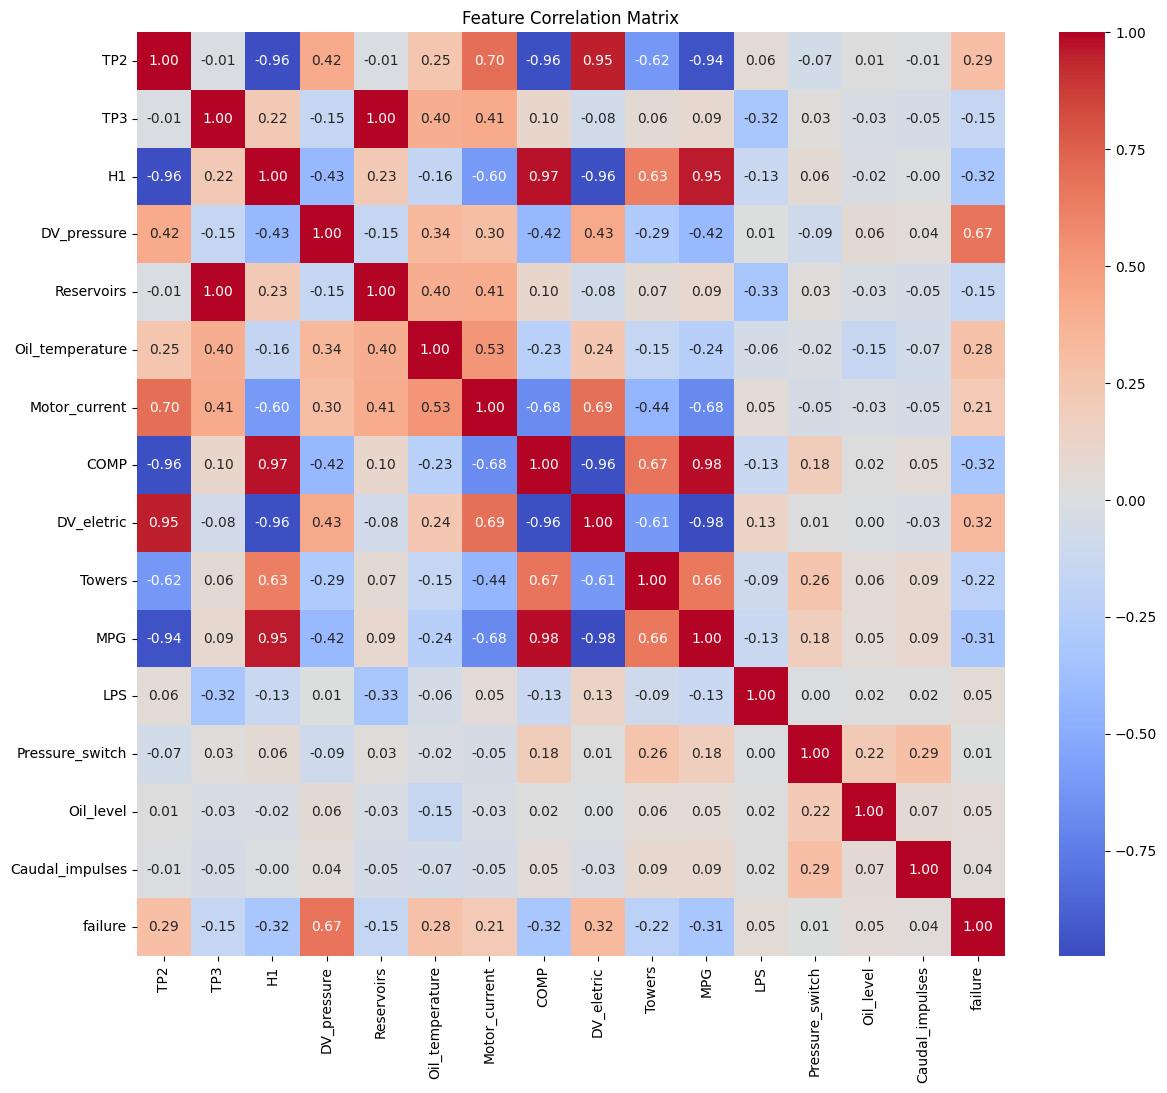

Top correlations with 'failure':
failure            1.000000
DV_pressure        0.669508
DV_eletric         0.322490
H1                 0.320653
COMP               0.319862
MPG                0.314913
TP2                0.294582
Oil_temperature    0.282155
Towers             0.218428
Motor_current      0.214681
Name: failure, dtype: float64


In [5]:
# Drop non-numeric/identifier columns for analysis
features_df = df.drop(['timestamp', 'Unnamed: 0'], axis=1)

plt.figure(figsize=(14, 12))
corr = features_df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

# Print correlation values specific to the target
print("Top correlations with 'failure':")
print(corr['failure'].abs().sort_values(ascending=False).head(10))

## 4. PCA Extraction (Task 3)
Standardizing the data and determining the optimal number of components. Note that scaling is required before PCA.

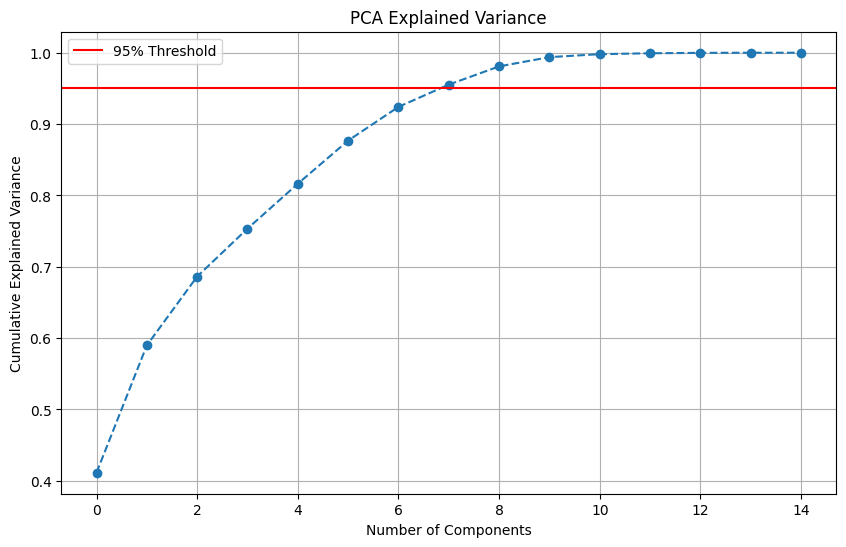

Number of components selected: 8


In [6]:
# Separate Features and Target
X_raw = df.drop(['timestamp', 'Unnamed: 0', 'failure'], axis=1)
y_raw = df['failure']

# 1. Scale the Data (Mandatory for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# 2. Fit PCA to see variance ratio
pca_test = PCA()
pca_test.fit(X_scaled)

# 3. Plot Cumulative Variance
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca_test.explained_variance_ratio_), marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.legend()
plt.grid()
plt.show()

# 4. Extract Components retaining 95% variance
n_components = np.argmax(np.cumsum(pca_test.explained_variance_ratio_) >= 0.95) + 1
print(f"Number of components selected: {n_components}")

# Apply final PCA transformation
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

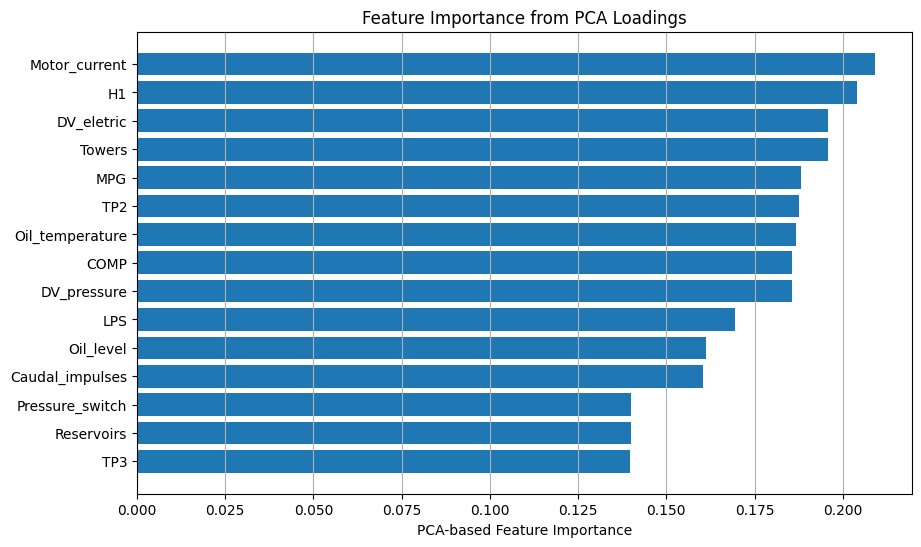

In [7]:
# PCA loadings
loadings = pca.components_.T  

# Weight loadings by explained variance
explained_var = pca.explained_variance_ratio_
weighted_loadings = loadings * explained_var

# Aggregate importance per original feature
feature_importance = np.sum(np.abs(weighted_loadings), axis=1)

# Create dataframe
importance_df = pd.DataFrame({
    'Feature': X_raw.columns,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()
plt.xlabel('PCA-based Feature Importance')
plt.title('Feature Importance from PCA Loadings')
plt.grid(axis='x')
plt.show()

## 5. Handling Class Imbalance (Task 4)
The dataset has ~15 million samples but only ~15k failures. This severe imbalance (0.1%) makes training standard models impossible on typical hardware and biases results.

**Strategy:** Undersampling the majority class to create a balanced dataset for efficient training.

In [8]:
# Create temporary dataframe for resampling
data_pca = pd.DataFrame(X_pca)
data_pca['target'] = y_raw.values

# Split by class
df_majority = data_pca[data_pca.target == 0]
df_minority = data_pca[data_pca.target == 1]

print(f"Majority class count: {len(df_majority)}")
print(f"Minority class count: {len(df_minority)}")

# Undersample majority class
# We aim for a 1:1 ratio or slightly higher (e.g., 2:1) to keep the dataset manageable
df_majority_downsampled = resample(df_majority, 
                                   replace=False,    
                                   n_samples=len(df_minority), # Balanced 1:1
                                   random_state=42) 

# Combine minority class with downsampled majority class
df_balanced = pd.concat([df_majority_downsampled, df_minority])

print("Balanced Dataset Shape:", df_balanced.shape)
print(df_balanced['target'].value_counts())

# Prepare final arrays
X_final = df_balanced.drop('target', axis=1).values
y_final = df_balanced['target'].values

Majority class count: 1486994
Minority class count: 29954
Balanced Dataset Shape: (59908, 9)
target
0    29954
1    29954
Name: count, dtype: int64


## 6. Data Splitting (Task 5)
Splitting into Training, Validation, and Test sets.

In [9]:
# 70% Train, 30% Temp
X_train, X_temp, y_train, y_temp = train_test_split(X_final, y_final, test_size=0.3, random_state=42)

# Split Temp into 50% Val, 50% Test (15% each of total)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train size: {len(X_train)}")
print(f"Validation size: {len(X_val)}")
print(f"Test size: {len(X_test)}")

Train size: 41935
Validation size: 8986
Test size: 8987


## 7. Model Training & Evaluation (Task 6 & 7)
Training SVM (RBF, Poly), KNN, and MLP. Reporting Accuracy, Precision, Recall, F1, and plotting ROC curves.


Training KNN
Validation Accuracy: 0.9940

--- Classification Report (KNN) ---
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      4486
           1       0.99      1.00      0.99      4501

    accuracy                           0.99      8987
   macro avg       0.99      0.99      0.99      8987
weighted avg       0.99      0.99      0.99      8987



<Figure size 800x600 with 0 Axes>

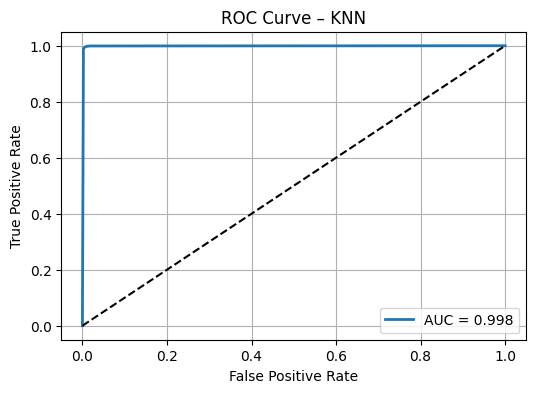

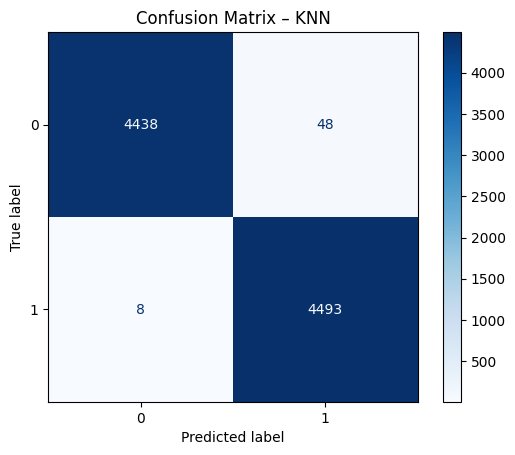


Training SVM_RBF
Validation Accuracy: 0.9889

--- Classification Report (SVM_RBF) ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      4486
           1       0.98      1.00      0.99      4501

    accuracy                           0.99      8987
   macro avg       0.99      0.99      0.99      8987
weighted avg       0.99      0.99      0.99      8987



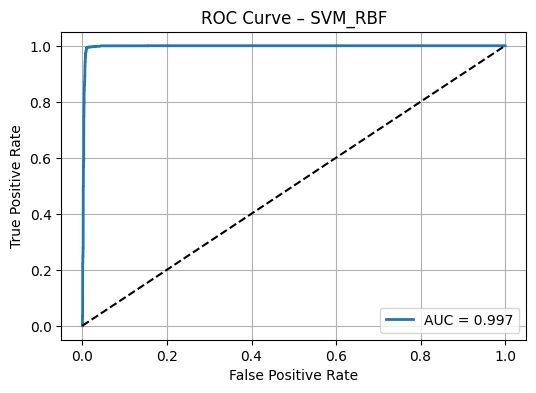

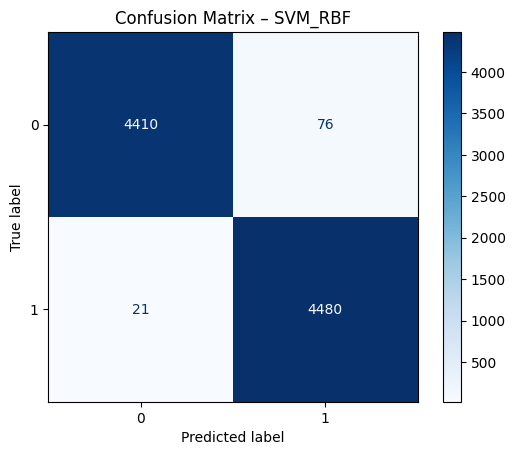


Training SVM_Poly
Validation Accuracy: 0.9875

--- Classification Report (SVM_Poly) ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      4486
           1       0.98      1.00      0.99      4501

    accuracy                           0.99      8987
   macro avg       0.99      0.99      0.99      8987
weighted avg       0.99      0.99      0.99      8987



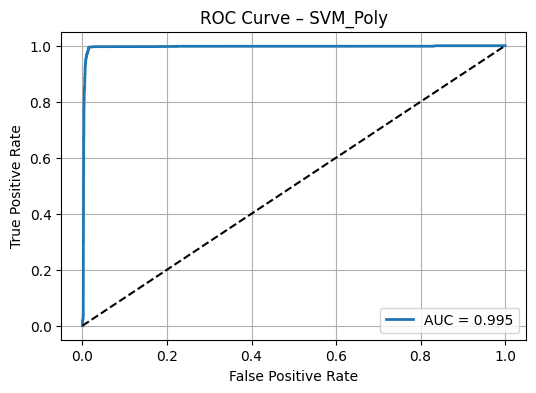

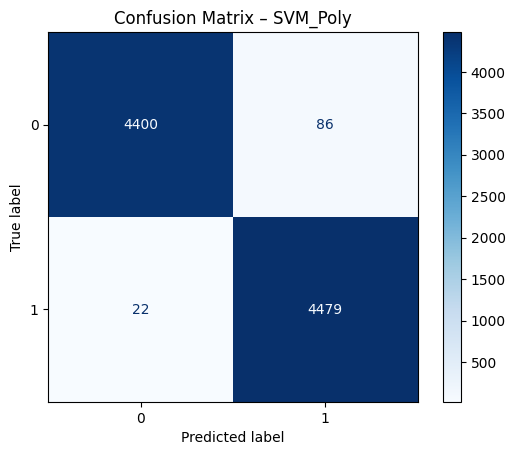


Training MLP
Validation Accuracy: 0.9919

--- Classification Report (MLP) ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4486
           1       0.99      0.99      0.99      4501

    accuracy                           0.99      8987
   macro avg       0.99      0.99      0.99      8987
weighted avg       0.99      0.99      0.99      8987



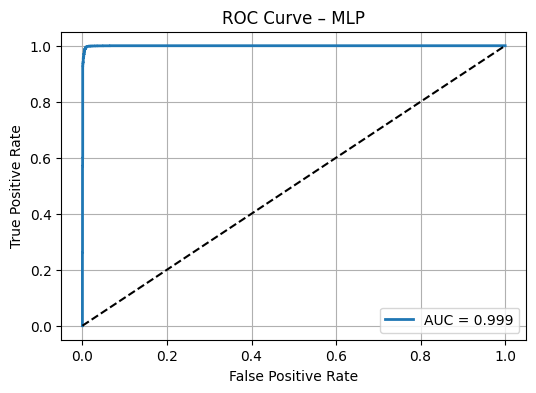

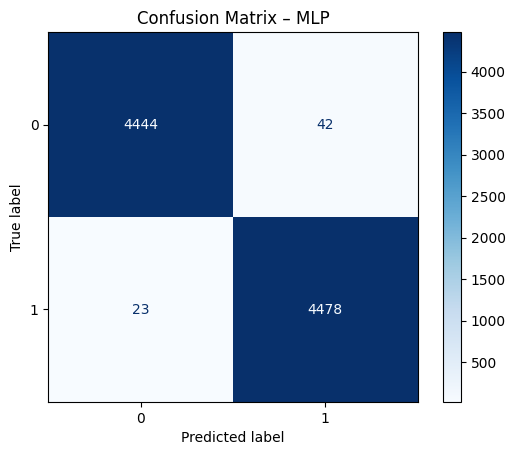

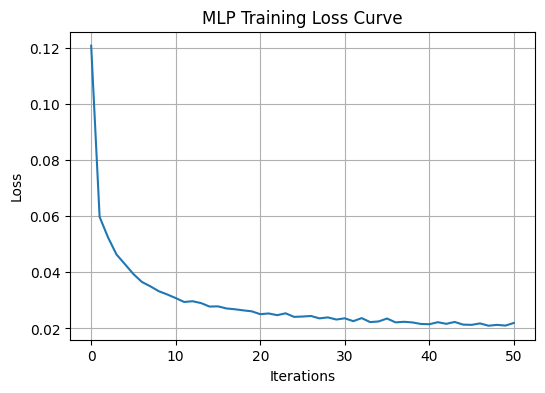


=== FINAL TEST METRICS ===
      Model  Accuracy  Precision    Recall        F1
0       KNN  0.993769   0.989430  0.998223  0.993807
1   SVM_RBF  0.989207   0.983319  0.995334  0.989290
2  SVM_Poly  0.987983   0.981161  0.995112  0.988087
3       MLP  0.992767   0.990708  0.994890  0.992795


In [10]:

# ================================
# MODELS
# ================================
models = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM_RBF': SVC(kernel='rbf', probability=True, random_state=42),
    'SVM_Poly': SVC(kernel='poly', degree=3, probability=True, random_state=42),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(100, 50),
        max_iter=300,
        random_state=42,
        early_stopping=True
    )
}

metrics_summary = []

# ================================
# COMBINED ROC FIGURE
# ================================
plt.figure(figsize=(8, 6))

for name, model in models.items():
    print(f"\n{'='*30}\nTraining {name}\n{'='*30}")

    # ---------- Train ----------
    model.fit(X_train, y_train)

    # ---------- Validation ----------
    val_pred = model.predict(X_val)
    val_acc = accuracy_score(y_val, val_pred)
    print(f"Validation Accuracy: {val_acc:.4f}")

    # ---------- Test ----------
    test_pred = model.predict(X_test)

    acc = accuracy_score(y_test, test_pred)
    prec = precision_score(y_test, test_pred)
    rec = recall_score(y_test, test_pred)
    f1 = f1_score(y_test, test_pred)

    metrics_summary.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1
    })

    print(f"\n--- Classification Report ({name}) ---")
    print(classification_report(y_test, test_pred))

    # ---------- ROC ----------
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    # --- Per-model ROC ---
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {name}")
    plt.legend()
    plt.grid()
    plt.show()

    # ---------- Confusion Matrix ----------
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        test_pred,
        cmap="Blues"
    )
    plt.title(f"Confusion Matrix – {name}")
    plt.show()

    # ---------- MLP Loss Curve ----------
    if name == 'MLP':
        plt.figure(figsize=(6, 4))
        plt.plot(model.loss_curve_)
        plt.xlabel("Iterations")
        plt.ylabel("Loss")
        plt.title("MLP Training Loss Curve")
        plt.grid()
        plt.show()



# ================================
# METRICS TABLE
# ================================
metrics_df = pd.DataFrame(metrics_summary)
print("\n=== FINAL TEST METRICS ===")
print(metrics_df)


Validation Accuracy Curve — KNN


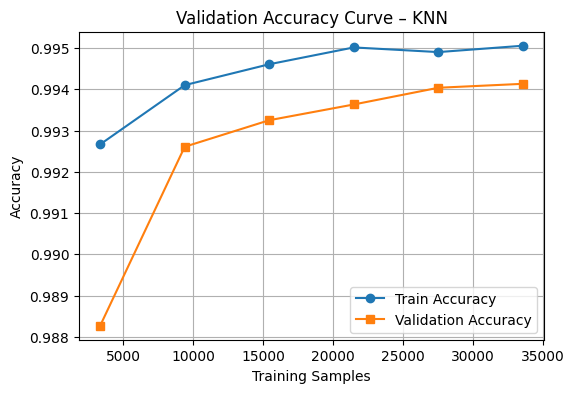


Validation Accuracy Curve — SVM_RBF


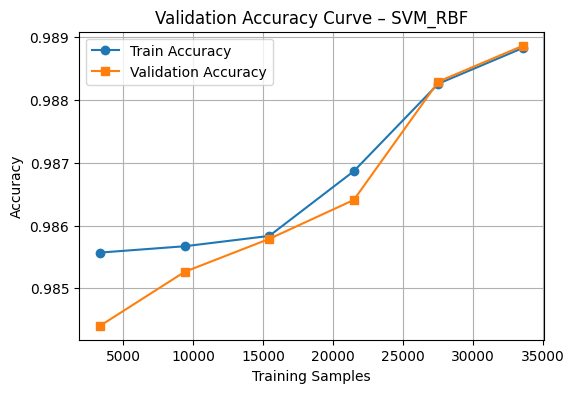


Validation Accuracy Curve — SVM_Poly


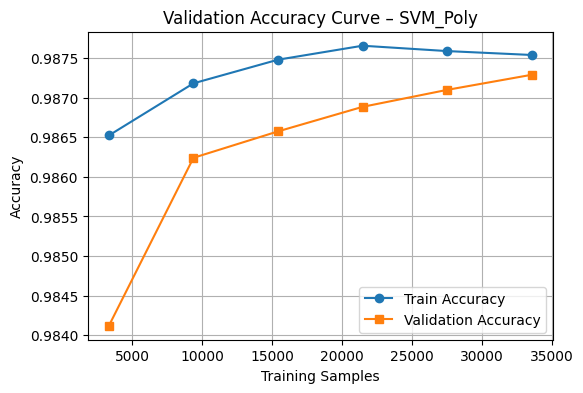


Validation Accuracy Curve — MLP


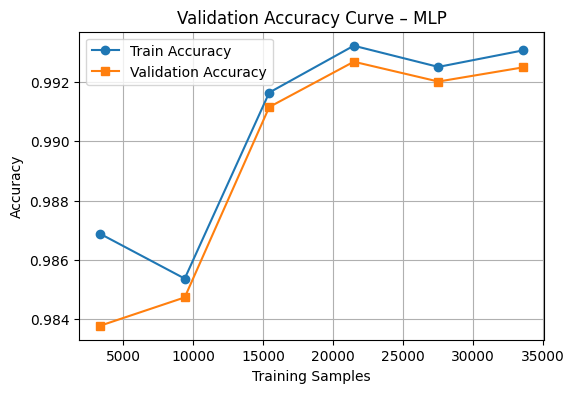

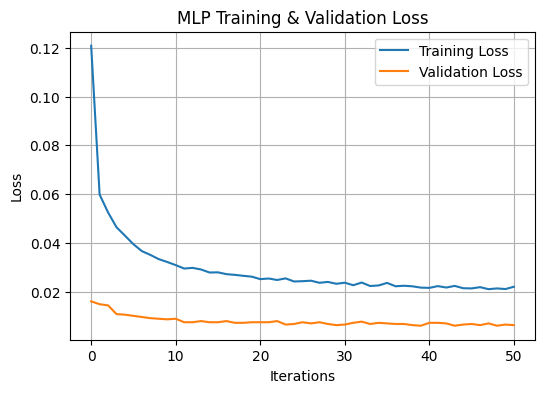

In [11]:

for name, model in models.items():
    print(f"\nValidation Accuracy Curve — {name}")

    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy",
        train_sizes=np.linspace(0.1, 1.0, 6),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.figure(figsize=(6, 4))
    plt.plot(train_sizes, train_mean, marker='o', label="Train Accuracy")
    plt.plot(train_sizes, val_mean, marker='s', label="Validation Accuracy")
    plt.xlabel("Training Samples")
    plt.ylabel("Accuracy")
    plt.title(f"Validation Accuracy Curve – {name}")
    plt.legend()
    plt.grid()
    plt.show()

# ================================
# VALIDATION LOSS (MLP ONLY)
# ================================
mlp = models["MLP"]

plt.figure(figsize=(6, 4))
plt.plot(mlp.loss_curve_, label="Training Loss")

# validation_scores_ exists ONLY when early_stopping=True
if hasattr(mlp, "validation_scores_"):
    plt.plot(
        np.arange(len(mlp.validation_scores_)),
        1 - np.array(mlp.validation_scores_),
        label="Validation Loss"
    )

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("MLP Training & Validation Loss")
plt.legend()
plt.grid()
plt.show()

## 8. Hyperparameter Tuning (Task 35)
Using Grid Search to optimize parameters for each model and comparing results.

In [12]:
param_grids = {

    "KNN": {
        "n_neighbors": [3, 5, 7, 11],
        "weights": ["uniform", "distance"],
        "metric": ["euclidean", "manhattan"]
    },

    "SVM_RBF": {
        "C": [0.1, 1, 10],
        "gamma": ["scale", 0.01, 0.1]
    },

    "SVM_Poly": {
        "C": [0.1, 1, 10],
        "degree": [2, 3, 4],
        "gamma": ["scale"]
    },

    "MLP": {
        "hidden_layer_sizes": [(50,), (100,), (100, 50)],
        "alpha": [1e-4, 1e-3],
        "learning_rate_init": [0.001, 0.01]
    }
}

In [13]:
from sklearn.model_selection import StratifiedKFold


In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_models = {}
grid_results = []

In [15]:
for name, model in models.items():
    print(f"\n{'='*40}")
    print(f"Grid Search for {name}")
    print(f"{'='*40}")

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        scoring="f1",          # or "roc_auc"
        cv=cv,
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

    print(f"Best params for {name}: {grid.best_params_}")
    print(f"Best CV score ({name}): {grid.best_score_:.4f}")

    best_models[name] = grid.best_estimator_

    grid_results.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "CV F1": grid.best_score_
    })


Grid Search for KNN
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params for KNN: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best CV score (KNN): 0.9944

Grid Search for SVM_RBF
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best params for SVM_RBF: {'C': 10, 'gamma': 0.1}
Best CV score (SVM_RBF): 0.9938

Grid Search for SVM_Poly
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best params for SVM_Poly: {'C': 10, 'degree': 4, 'gamma': 'scale'}
Best CV score (SVM_Poly): 0.9919

Grid Search for MLP
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params for MLP: {'alpha': 0.001, 'hidden_layer_sizes': (100, 50), 'learning_rate_init': 0.01}
Best CV score (MLP): 0.9930


In [16]:
models = best_models

In [17]:
grid_df = pd.DataFrame(grid_results)
print("\n=== GRID SEARCH SUMMARY ===")
print(grid_df)


=== GRID SEARCH SUMMARY ===
      Model                                        Best Params     CV F1
0       KNN  {'metric': 'manhattan', 'n_neighbors': 3, 'wei...  0.994376
1   SVM_RBF                            {'C': 10, 'gamma': 0.1}  0.993750
2  SVM_Poly           {'C': 10, 'degree': 4, 'gamma': 'scale'}  0.991851
3       MLP  {'alpha': 0.001, 'hidden_layer_sizes': (100, 5...  0.993004
